# 1. 工具节点内审批

In [2]:
from typing import Literal
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from rich import print
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from dotenv import load_dotenv
from langgraph.types import interrupt, Command
from langchain_core.messages import ToolMessage

load_dotenv(override=True)

model = init_chat_model(
    model_provider="deepseek",
    model="deepseek-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 定义工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """根据城市名称查询天气

    Args:
        city (str): 城市名称

    Returns:
        str: 城市天气情况
    """
    return f"{city} 的天气是晴天，温度 25°C"


@tool(parse_docstring=True)
def get_news(topic: Literal["科技", "体育", "娱乐"]) -> str:
    """根据主题查询新闻

    Args:
        topic (Literal["科技", "体育", "娱乐"]): 新闻主题

    Returns:
        str: 新闻内容
    """
    return {
        "科技": "最新科技新闻：AI 技术正在快速发展。",
        "体育": "最新体育新闻：中国队取得了胜利。",
        "娱乐": "最新娱乐新闻：歌手发布了新专辑。",
    }[topic]


tools = [get_weather, get_news]
model_with_tools = model.bind_tools(tools=tools)


# 定义状态
class State(MessagesState):
    pass


NEVER_ASK = {}


def need_approval(name: str, args: dict):
    return name not in NEVER_ASK


def tool_node(state: State) -> dict:
    last = state["messages"][-1]
    tool_map = {t.name: t for t in tools}

    # 1.收集所有审批决策
    decisions = {}
    for tc in last.tool_calls:
        if need_approval(tc['name'], tc['args']):
            decisions[tc['id']] = interrupt({"name": tc["name"], "args": tc["args"]})
        else:
            decisions[tc['id']] = True

    # 2. 决策齐了统一执行
    messages = []
    for tc in last.tool_calls:
        selected = tool_map.get(tc['name'])
        approved = decisions.get(tc['id'])
        if not selected:
            res = f"未知工具: {tc['name']}，请勿重试"
        elif not approved:
            res = f"用户拒绝执行 {tc['name']}，请勿重试，直接回答"
        else:
            res = tool_map[tc['name']].invoke(tc['args'])

        messages.append(ToolMessage(content=str(res), tool_call_id=tc['id']))

    return Command(goto="llm_node", update={"messages": messages})


def llm_node(state: State) -> Command[Literal["tool_node", END]]:
    ai_msg = model_with_tools.invoke(state["messages"])
    goto = "tool_node" if ai_msg.tool_calls else END
    return Command(goto=goto, update={"messages": [ai_msg]})


builder = StateGraph(state_schema=State)
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)
builder.add_edge(START, "llm_node")

checkpointer = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}
graph = builder.compile(checkpointer)

res = graph.invoke({"messages": [HumanMessage("帮我查一下北京的天气和科技相关的新闻")]}, config=config)
print(res)

{
    'messages': [
        HumanMessage(
            content='帮我查一下北京的天气和科技相关的新闻',
            additional_kwargs={},
            response_metadata={},
            id='cc16c544-6a34-4f2c-987a-50a494596f5b'
        ),
        AIMessage(
            content='我来帮您查询北京的天气和科技新闻。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 76,
                    'prompt_tokens': 345,
                    'total_tokens': 421,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 128,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 128,
                    'prompt_cache_miss_tokens': 217
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': '64b5fd38-6a58-4629-9fe0-2b57b84480a2',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0b0c2-582d-7db1-b5d1-b8049ef61c83-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_UTVPA2q33OYB2Eb4Aa636169',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_news',
                    'args': {'topic': '科技'},
                    'id': 'call_01_otO2t3VpqegdGx8dRAS02678',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 345,
                'output_tokens': 76,
                'total_tokens': 421,
                'input_token_details': {'cache_read': 128},
                'output_token_details': {}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(value={'name': 'get_weather', 'args': {'city': '北京'}}, id='aa42d2bdca5b082a589998650467f02b')
    ]
}

In [3]:
while res.get("__interrupt__"):
    info = res["__interrupt__"][0].value
    ans = input(f"允许 {info['name']}({info['args']})? (y/n) ").strip().lower() in ("y", "yes", "是", "1")
    res = graph.invoke(Command(resume=ans), config=config)  # ans 已经是 bool
print(res)

{
    'messages': [
        HumanMessage(
            content='帮我查一下北京的天气和科技相关的新闻',
            additional_kwargs={},
            response_metadata={},
            id='cc16c544-6a34-4f2c-987a-50a494596f5b'
        ),
        AIMessage(
            content='我来帮您查询北京的天气和科技新闻。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 76,
                    'prompt_tokens': 345,
                    'total_tokens': 421,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 128,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 128,
                    'prompt_cache_miss_tokens': 217
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': '64b5fd38-6a58-4629-9fe0-2b57b84480a2',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0b0c2-582d-7db1-b5d1-b8049ef61c83-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_UTVPA2q33OYB2Eb4Aa636169',
                    'type': 'tool_call'
                },
                {
                    'name': 'get_news',
                    'args': {'topic': '科技'},
                    'id': 'call_01_otO2t3VpqegdGx8dRAS02678',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 345,
                'output_tokens': 76,
                'total_tokens': 421,
                'input_token_details': {'cache_read': 128},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='北京 的天气是晴天，温度 25°C',
            id='be19b642-e26a-445e-bae7-9b5fe7da6a4e',
            tool_call_id='call_00_UTVPA2q33OYB2Eb4Aa636169'
        ),
        ToolMessage(
            content='最新科技新闻：AI 技术正在快速发展。',
            id='42127f6b-adc9-4765-bb84-8fa23783587a',
            tool_call_id='call_01_otO2t3VpqegdGx8dRAS02678'
        ),
        AIMessage(
            content='已为您查询到以下信息：\n\n**🌤️ 北京天气**\n- 天气：晴天\n- 温度：25°C\n\n**📰 科技新闻**\n- 
最新科技新闻：AI 技术正在快速发展。\n\n今天北京天气晴朗，气温 25°C，非常适合外出活动。另外，科技领域方面，AI 
技术正在快速发展，值得持续关注。如果您想了解更详细的科技新闻内容或其他城市的信息，随时告诉我！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 94,
                    'prompt_tokens': 462,
                    'total_tokens': 556,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 256,
                        'image_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_cache_hit_tokens': 256,
                    'prompt_cache_miss_tokens': 206
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-flash',
                'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                'id': '4053f524-ee2a-4b14-b35e-a1c93f2a2042',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0b0c2-7422-7923-acb3-7a35b2b07659-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input

In [4]:
print(list(graph.get_state_history(config=config)))

[
    StateSnapshot(
        values={
            'messages': [
                HumanMessage(
                    content='帮我查一下北京的天气和科技相关的新闻',
                    additional_kwargs={},
                    response_metadata={},
                    id='cc16c544-6a34-4f2c-987a-50a494596f5b'
                ),
                AIMessage(
                    content='我来帮您查询北京的天气和科技新闻。',
                    additional_kwargs={'refusal': None},
                    response_metadata={
                        'token_usage': {
                            'completion_tokens': 76,
                            'prompt_tokens': 345,
                            'total_tokens': 421,
                            'completion_tokens_details': None,
                            'prompt_tokens_details': {
                                'audio_tokens': None,
                                'cache_write_tokens': None,
                                'cached_tokens': 128,
                                'image_tokens': None,
                                'text_tokens': None
                            },
                            'prompt_cache_hit_tokens': 128,
                            'prompt_cache_miss_tokens': 217
                        },
                        'model_provider': 'deepseek',
                        'model_name': 'deepseek-flash',
                        'system_fingerprint': 'aeb56401ca74e127821c4f9126dcb669',
                        'id': '64b5fd38-6a58-4629-9fe0-2b57b84480a2',
                        'finish_reason': 'tool_calls',
                        'logprobs': None
                    },
                    id='lc_run--01a0b0c2-582d-7db1-b5d1-b8049ef61c83-0',
                    tool_calls=[
                        {
                            'name': 'get_weather',
                            'args': {'city': '北京'},
                            'id': 'call_00_UTVPA2q33OYB2Eb4Aa636169',
                            'type': 'tool_call'
                        },
                        {
                            'name': 'get_news',
                            'args': {'topic': '科技'},
                            'id': 'call_01_otO2t3VpqegdGx8dRAS02678',
                            'type': 'tool_call'
                        }
                    ],
                    invalid_tool_calls=[],
                    usage_metadata={
                        'input_tokens': 345,
                        'output_tokens': 76,
                        'total_tokens': 421,
                        'input_token_details': {'cache_read': 128},
                        'output_token_details': {}
                    }
                ),
                ToolMessage(
                    content='北京 的天气是晴天，温度 25°C',
                    id='be19b642-e26a-445e-bae7-9b5fe7da6a4e',
                    tool_call_id='call_00_UTVPA2q33OYB2Eb4Aa636169'
                ),
                ToolMessage(
                    content='最新科技新闻：AI 技术正在快速发展。',
                    id='42127f6b-adc9-4765-bb84-8fa23783587a',
                    tool_call_id='call_01_otO2t3VpqegdGx8dRAS02678'
                ),
                AIMessage(
                    content='已为您查询到以下信息：\n\n**🌤️ 北京天气**\n- 天气：晴天\n- 温度：25°C\n\n**📰 
科技新闻**\n- 最新科技新闻：AI 技术正在快速发展。\n\n今天北京天气晴朗，气温 
25°C，非常适合外出活动。另外，科技领域方面，AI 
技术正在快速发展，值得持续关注。如果您想了解更详细的科技新闻内容或其他城市的信息，随时告诉我！',
                    additional_kwargs={'refusal': None},
                    response_metadata={
                        'token_usage': {
                            'completion_tokens': 94,
                            'prompt_tokens': 462,
                            'total_tokens': 556,
                            'completion_tokens_details': None,
                            'prompt_tokens_details': {
                                'audio_tokens': None,
                                'cache_write_tokens': None,
                                'cached_tokens': 256,
                                'image_tokens': None,
  

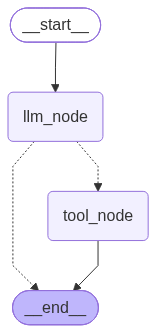

None

In [5]:
from IPython.display import display

print(display(graph))